# Policy Gradients: REINFORCE Baseline with LunarLander

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
from IPython import display
from pathlib import Path

In [2]:
# check and use GPU if available if not use CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


### LunarLander

LunarLander is an OpenAI gym environment (env). In this env the agent tries to land a space craft safely on the ground by firing the main, left, or right engine. The agent receives a reward for navigating to the landing pad and turning off the engine, a large reward for a safe landing, a large negative reward for an unsafe landing, and a small negative reward for using the engines. There are discrete and continuous versions of LunarLander.

In [3]:
render_in_notebook = False  # True for notebook playback, False only if using a normal .py script

# when using Ubuntu 22.04
env = gym.make('LunarLander-v3', render_mode='rgb_array' if render_in_notebook else 'human')
# when using MacOS
#env = gym.make('LunarLander-v3')
state, info = env.reset(seed=0)

for i in range(200):
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)

    if render_in_notebook:
        plt.imshow(env.render())
        plt.axis('off')
        display.clear_output(wait=True)
        display.display(plt.gcf())

    if terminated or truncated:
        state, info = env.reset()

env.close()
plt.close()

### Policy Gradient Methods

In policy gradient methods, we update the policy directly. Ie we parameterize the policy and perform gradient descent updates on the policy parameters seeking to improve the policy. This is in contrast to section 3 where we learned estimates of the state or action-values. Then we extracted a policy based on those values, like with the epsilon greedy DQN policy.

### Discrete vs. Continuous Action Spaces

PG methods can work in discrete and continuous action spaces. The DQN method we went over in section three required discrete action spaces: ie a limited number of actions. In continuous actions spaces there are an infinite number of actions as the action can be any value in a range. Continuous action spaces are often parameterized by a probability distribution and we learn the parameters of the distribution. For example we assume the actions come from a Gaussian distribution and try to learn the mean and standard deviation of the Gaussian that leads to the best policy. 

### REINFORCE with Lunar Lander

In this example, we will solve the discrete version of Lunar Lander using the REINFORCE with baseline method.

### 1. Initialise the Agent

In [4]:
class ActorNet(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super(ActorNet, self).__init__()
        self.dense_layer_1 = nn.Linear(state_size, hidden_size)
        self.dense_layer_2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, action_size)
    
    def forward(self, x):
        x = torch.clamp(x, -1.1, 1.1)
        x = F.relu(self.dense_layer_1(x))
        x = F.relu(self.dense_layer_2(x))
        return F.softmax(self.output(x),dim=-1) #-1 to take softmax of last dimension
    
class ValueFunctionNet(nn.Module):
    def __init__(self, state_size, hidden_size):
        super(ValueFunctionNet, self).__init__()
        self.dense_layer_1 = nn.Linear(state_size, hidden_size)
        self.dense_layer_2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        x = torch.clamp(x, -1.1, 1.1)
        x = F.relu(self.dense_layer_1(x))
        x = F.relu(self.dense_layer_2(x))
        return self.output(x)

In [5]:
class PGAgent():
    def __init__(self, state_size, action_size, hidden_size, actor_lr, vf_lr, discount, entropy_coef):
        self.action_size = action_size
        self.actor_net = ActorNet(state_size, action_size, hidden_size).to(device)
        self.vf_net = ValueFunctionNet(state_size, hidden_size).to(device)
        self.actor_optimizer = optim.Adam(self.actor_net.parameters(), lr=actor_lr)
        self.vf_optimizer = optim.Adam(self.vf_net.parameters(), lr=vf_lr)
        self.discount = discount
        self.entropy_coef = entropy_coef
        
    def select_action(self, state, deterministic=False):
        with torch.no_grad():
            input_state = torch.as_tensor(state, dtype=torch.float32, device=device)
            action_probs = self.actor_net(input_state)
            if deterministic:
                action = torch.argmax(action_probs)
            else:
                action = torch.distributions.Categorical(action_probs).sample()
        return action.item()

    def train(self, state_list, action_list, reward_list):
        
        # turn rewards into return
        trajectory_len = len(reward_list)
        return_array = np.zeros((trajectory_len,))
        g_return = 0.0
        for i in range(trajectory_len - 1, -1, -1):
            g_return = reward_list[i] + self.discount * g_return
            return_array[i] = g_return

        # create tensors
        state_t = torch.as_tensor(np.array(state_list), dtype=torch.float32, device=device)
        action_t = torch.as_tensor(action_list, dtype=torch.long, device=device).view(-1, 1)
        return_t = torch.as_tensor(return_array, dtype=torch.float32, device=device).view(-1, 1)
        
        # get value function estimates
        vf_t = self.vf_net(state_t)
        with torch.no_grad():
            advantage_t = return_t - vf_t
            # add advantage normalization
            advantage_t = (advantage_t - advantage_t.mean()) / (advantage_t.std(unbiased=False) + 1e-8)
        
        # calculate actor loss
        action_probs = self.actor_net(state_t)
        selected_action_prob = action_probs.gather(1, action_t)

        # entropy bonus
        entropy = -(action_probs * torch.log(action_probs + 1e-8)).sum(dim=1).mean()

        # REINFORCE Baseline loss + entropy regularization
        actor_loss = torch.mean(-torch.log(selected_action_prob + 1e-8) * advantage_t) - self.entropy_coef * entropy

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        # add clipping
        torch.nn.utils.clip_grad_norm_(self.actor_net.parameters(), max_norm=1.0)
        self.actor_optimizer.step()

        # calculate vf loss
        loss_fn = nn.MSELoss()
        vf_loss = loss_fn(vf_t, return_t)
        self.vf_optimizer.zero_grad()
        vf_loss.backward()
        # add clipping
        torch.nn.utils.clip_grad_norm_(self.vf_net.parameters(), max_norm=1.0)
        self.vf_optimizer.step()
        
        return actor_loss.detach().cpu().item(), vf_loss.detach().cpu().item()
    

### 2. Set up the environment

In [6]:
# initialize environment
env = gym.make('LunarLander-v3', render_mode='rgb_array')
eval_env = gym.make('LunarLander-v3', render_mode='rgb_array')
action_size = env.action_space.n
state_size = env.observation_space.shape[0]

# set seed
seed = 31
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# hyperparameters
episodes = 2000 # run agent for this many episodes
hidden_size = 64 # number of units in NN hidden layers
actor_lr = 0.001 # learning rate for actor
value_function_lr = 0.002 # learning rate for value function
discount = 0.99 # discount factor gamma value
reward_scale = 1.0 #scale reward by this amount # Config B change
entropy_coef = 1e-3         # Config B added

# create agent
agent = PGAgent(
    state_size,
    action_size,
    hidden_size,
    actor_lr,
    value_function_lr,
    discount,
    entropy_coef # Config B added
)
# evaluation + checkpoint setup
eval_every = 50
eval_episodes = 10
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_eval_mean = -np.inf
best_checkpoint_path = checkpoint_dir / "lunarlander_reinforce_baseline_best.pt"

# guarantees the checkpoint belongs to the current run
if best_checkpoint_path.exists():
    best_checkpoint_path.unlink()

eval_history = []

def evaluate_policy(agent, eval_env, num_episodes, eval_seed_base):
    eval_rewards = []
    eval_lengths = []

    for eval_ep in range(num_episodes):
        state, info = eval_env.reset(seed=eval_seed_base + eval_ep)
        done = False
        total_reward = 0.0
        episode_length = 0

        while not done:
            action = agent.select_action(state, deterministic=True)
            state, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward
            episode_length += 1

        eval_rewards.append(total_reward)
        eval_lengths.append(episode_length)

    return float(np.mean(eval_rewards)), float(np.std(eval_rewards)), float(np.mean(eval_lengths))

# Load the best checkpoint before watch video
def load_checkpoint_into_agent(agent, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    agent.actor_net.load_state_dict(checkpoint['actor_state_dict'])
    agent.vf_net.load_state_dict(checkpoint['value_state_dict'])
    return checkpoint

### 3. Train the Agent with REINFORCE with baseline

In [7]:
stats_rewards_list = [] # store stats for plotting in this
stats_every = 10 # print stats every this many episodes
timesteps = 0
stats_actor_loss, stats_vf_loss = 0.0, 0.0

for ep in range(episodes):
    # optional: use seed + ep for slightly different resets while remaining reproducible
    state, info = env.reset(seed=seed + ep)

    state_list, action_list, reward_list = [], [], []
    total_reward = 0.0
    episode_length = 0

    # # stopping condition for training if agent reaches the amount of reward
    # if len(stats_rewards_list) > stats_every and np.mean(stats_rewards_list[-stats_every:], axis=0)[1] > 190:
    #     print(
    #         "Stopping at episode {} with average rewards of {} in last {} episodes".format(
    #             ep, np.mean(stats_rewards_list[-stats_every:], axis=0)[1], stats_every
    #         )
    #     )
    #     break

    while True:
        timesteps += 1

        # select an action from the agent's policy
        action = agent.select_action(state)

        # enter action into the env
        next_state, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        total_reward += reward
        episode_length += 1

        # store agent's trajectory
        state_list.append(state)
        action_list.append(action)
        reward_list.append(reward * reward_scale)

        # end episode early
        if total_reward < -250:
            done = True

        if done:
            actor_loss, vf_loss = agent.train(state_list, action_list, reward_list)
            stats_rewards_list.append((ep, total_reward, episode_length))
            stats_actor_loss += actor_loss
            stats_vf_loss += vf_loss

            if (ep + 1) % stats_every == 0:
                recent = np.array(stats_rewards_list[-stats_every:])
                print(
                    'Episode: {}'.format(ep),
                    'Timestep: {}'.format(timesteps),
                    'Total reward: {:.1f}'.format(np.mean(recent[:, 1])),
                    'Episode length: {:.1f}'.format(np.mean(recent[:, 2])),
                    'Actor Loss: {:.4f}'.format(stats_actor_loss / stats_every),
                    'VF Loss: {:.4f}'.format(stats_vf_loss / stats_every)
                )
                stats_actor_loss, stats_vf_loss = 0.0, 0.0

            # add evaluation printing
            if (ep + 1) % eval_every == 0:
                eval_mean, eval_std, eval_len = evaluate_policy(
                    agent,
                    eval_env,
                    num_episodes=eval_episodes,
                    eval_seed_base=seed + 10000 + ep * eval_episodes,
                )
                eval_history.append((ep, eval_mean, eval_std, eval_len))
                print(
                    'Eval @ Episode: {}'.format(ep),
                    'Eval mean reward: {:.2f}'.format(eval_mean),
                    'Eval std reward: {:.2f}'.format(eval_std),
                    'Eval episode length: {:.1f}'.format(eval_len),
                )

                if eval_mean > best_eval_mean:
                    best_eval_mean = eval_mean
                    torch.save(
                        {
                            'episode': ep,
                            'eval_mean_reward': eval_mean,
                            'eval_std_reward': eval_std,
                            'eval_mean_length': eval_len,
                            'actor_state_dict': agent.actor_net.state_dict(),
                            'value_state_dict': agent.vf_net.state_dict(),
                            'actor_optimizer_state_dict': agent.actor_optimizer.state_dict(),
                            'value_optimizer_state_dict': agent.vf_optimizer.state_dict(),
                            'seed': seed,
                            'hidden_size': hidden_size,
                            'actor_lr': actor_lr,
                            'value_function_lr': value_function_lr,
                            'discount': discount,
                            'reward_scale': reward_scale,
                            'entropy_coef': entropy_coef,
                        },
                        best_checkpoint_path,
                    )
                    print(
                        'Saved new best checkpoint to {} with eval mean reward {:.2f}'.format(
                            best_checkpoint_path, eval_mean
                        )
                    )
                # NEW: early-stop by evaluation
                if best_eval_mean >= 200:
                    print(
                        'Stopping early because best eval mean reward reached {:.2f} at episode {}'.format(
                            best_eval_mean, ep
                        )
                    )
                    break
            break

        state = next_state
    
    if best_eval_mean >= 200:
        break

eval_env.close()

Episode: 9 Timestep: 862 Total reward: -184.0 Episode length: 86.2 Actor Loss: -0.0014 VF Loss: 12303.1699
Episode: 19 Timestep: 1813 Total reward: -143.0 Episode length: 95.1 Actor Loss: -0.0055 VF Loss: 6510.2971
Episode: 29 Timestep: 2741 Total reward: -182.0 Episode length: 92.8 Actor Loss: 0.0018 VF Loss: 10297.4219
Episode: 39 Timestep: 3709 Total reward: -163.3 Episode length: 96.8 Actor Loss: 0.0018 VF Loss: 8319.6746
Episode: 49 Timestep: 4637 Total reward: -187.8 Episode length: 92.8 Actor Loss: -0.0054 VF Loss: 11827.7698
Eval @ Episode: 49 Eval mean reward: -328.49 Eval std reward: 174.74 Eval episode length: 143.3
Saved new best checkpoint to checkpoints/lunarlander_reinforce_baseline_best.pt with eval mean reward -328.49
Episode: 59 Timestep: 5576 Total reward: -110.3 Episode length: 93.9 Actor Loss: -0.0081 VF Loss: 4654.9676
Episode: 69 Timestep: 6579 Total reward: -148.8 Episode length: 100.3 Actor Loss: -0.0084 VF Loss: 5937.7164
Episode: 79 Timestep: 7424 Total rewar

### 4. Plot the Scores

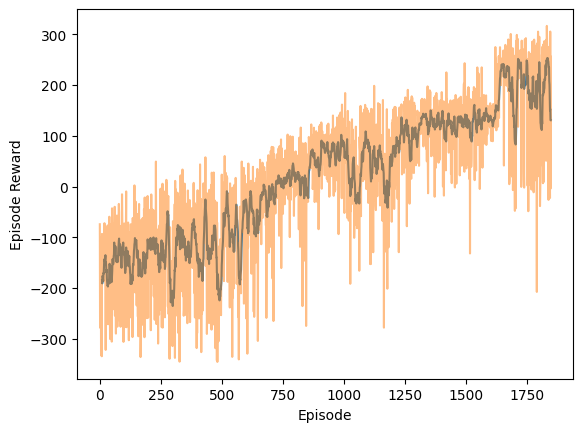

In [8]:
# plot stats
def get_running_stat(stat, stat_len):
    cum_sum = np.cumsum(np.insert(stat, 0, 0)) 
    return (cum_sum[stat_len:] - cum_sum[:-stat_len]) / stat_len

episode, r, l = np.array(stats_rewards_list).T
cum_r = get_running_stat(r, 10)
cum_l = get_running_stat(l, 10)

# plot rewards
plt.figure()
plt.plot(episode[-len(cum_r):], cum_r)
plt.plot(episode, r, alpha=0.5)
plt.xlabel('Episode')
plt.ylabel('Episode Reward')
plt.show()

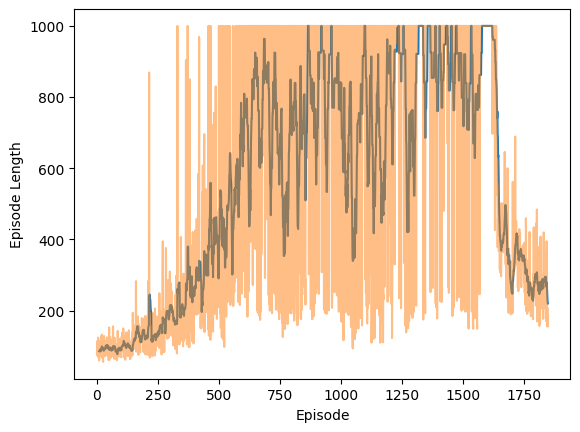

In [9]:
# plot episode lengths
plt.figure()
plt.plot(episode[-len(cum_l):], cum_l)
plt.plot(episode, l, alpha=0.5)
plt.xlabel('Episode')
plt.ylabel('Episode Length')
plt.show()

### 5. Watch your Trained Agent!

In [10]:
render_in_notebook = False # can be very laggy if True, set to False for faster training and to pop up in a separate window

# load best saved model before watching
if best_checkpoint_path.exists():
    checkpoint = load_checkpoint_into_agent(agent, best_checkpoint_path)
    print(
        "Loaded best checkpoint from episode {} with eval mean reward {:.2f}".format(
            checkpoint['episode'], checkpoint['eval_mean_reward']
        )
    )
else:
    print("No checkpoint found. Watching current in-memory agent.")

env = gym.make('LunarLander-v3', render_mode='rgb_array' if render_in_notebook else 'human')
state, info = env.reset(seed=0)

done = False
while not done:
    action = agent.select_action(state, deterministic=True)   # changed
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if render_in_notebook:
        plt.imshow(env.render())
        plt.axis('off')
        display.clear_output(wait=True)
        display.display(plt.gcf())

env.close()
plt.close()

Loaded best checkpoint from episode 1849 with eval mean reward 217.08


In [11]:
import os
from gymnasium.wrappers import RecordVideo

video_dir = "videos"
os.makedirs(video_dir, exist_ok=True)

# load best saved model before recording
if best_checkpoint_path.exists():
    checkpoint = load_checkpoint_into_agent(agent, best_checkpoint_path)
    print(
        "Loaded best checkpoint for video from episode {} with eval mean reward {:.2f}".format(
            checkpoint['episode'], checkpoint['eval_mean_reward']
        )
    )

# For recording, use rgb_array
env = gym.make("LunarLander-v3", render_mode="rgb_array")

# Record this episode as an mp4
env = RecordVideo(
    env,
    video_folder=video_dir,
    name_prefix="lunarlander_eval",
    episode_trigger=lambda episode_id: True  # record every episode
)

state, info = env.reset(seed=0)

done = False
while not done:
    action = agent.select_action(state, deterministic=True)
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()

print(f"Saved video to folder: {video_dir}")

Loaded best checkpoint for video from episode 1849 with eval mean reward 217.08


/home/msakal2024@fit.edu/TKRM/RLClass/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/msakal2024@fit.edu/TKRM/RLClass/reinforce/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video to folder: videos
